# Waveform Square Attack: A Black-Box Attack on Audio

`attacks/whitebox/01_FGSM.ipynb` and `attacks/whitebox/02_PGD.ipynb` both need the model's gradient. This notebook removes
that assumption, the audio counterpart of `attacks/SquareAttack.ipynb` in the companion vision
repo (Andriushchenko et al., 2020): the model is only ever queried for its output probabilities,
never differentiated. The vision version perturbs random square patches of pixels; here, with no
2D structure to exploit, the natural analogue is a random contiguous **segment** of the waveform.

Each iteration proposes flipping the sign of a small random segment's perturbation, evaluates the
true class's probability with one forward pass, and keeps the change only if it made things worse
for the correct class, the same greedy, query-only acceptance rule as the vision version.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

def _load_wav(path, frame_offset=0, num_frames=-1, normalize=True, channels_first=True, format=None, buffer_size=4096, backend=None):
    """Replaces torchaudio's TorchCodec-based loader (needs a separately installed FFmpeg, not
    available here) with soundfile, which reads WAV directly with no extra system dependencies."""
    data, sample_rate = sf.read(path, dtype='float32')
    waveform = torch.from_numpy(data)
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(1)
    if channels_first:
        waveform = waveform.transpose(0, 1)
    return waveform, sample_rate

torchaudio.load = _load_wav

### Setup: Model and Test Clips
Same target model and the same 10 held-out clips attacked in `attacks/whitebox/01_FGSM.ipynb` and
`attacks/whitebox/02_PGD.ipynb`, for a direct three-way comparison.

In [2]:
import os

LABELS = ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
LABEL_TO_IDX = {label: i for i, label in enumerate(LABELS)}
SAMPLE_RATE = 16000

mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE, n_mels=64, n_fft=400, hop_length=160)
to_db = torchaudio.transforms.AmplitudeToDB()

def waveform_to_spectrogram(waveform):
    return to_db(mel_spectrogram(waveform))

class KeywordCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, spectrogram):
        x = self.pool(F.relu(self.bn1(self.conv1(spectrogram))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).flatten(1)
        return self.fc(x)

model = KeywordCNN(num_classes=len(LABELS))
model.load_state_dict(torch.load('../models/keyword_spotter.pth', map_location='cpu'))
model.eval()

os.makedirs('../models/speech_commands_data', exist_ok=True)
test_data = torchaudio.datasets.SPEECHCOMMANDS(root='../models/speech_commands_data', download=True, subset='testing')

def pad_or_trim(waveform):
    if waveform.shape[1] < SAMPLE_RATE:
        return F.pad(waveform, (0, SAMPLE_RATE - waveform.shape[1]))
    return waveform[:, :SAMPLE_RATE]

sample_clips = {}
for i in range(len(test_data)):
    waveform, sr, label, *_ = test_data[i]
    if label in LABEL_TO_IDX and label not in sample_clips:
        sample_clips[label] = pad_or_trim(waveform)
    if len(sample_clips) == len(LABELS):
        break

print(f"Loaded model and {len(sample_clips)} sample clips")

Loaded model and 10 sample clips


### The Attack
At each query: pick a random segment (5-10% of the waveform's length) and a random sign, apply it
at fixed amplitude $\varepsilon$ on top of the current perturbation, and keep the proposal only if
it lowers the true class's probability (a strict improvement), otherwise discard it and try again
next query, the same greedy, one-query-per-step acceptance rule as `attacks/SquareAttack.ipynb`.

In [3]:
@torch.no_grad()
def true_class_prob(waveform, true_label_idx):
    logits = model(waveform_to_spectrogram(waveform.unsqueeze(0)))
    probs = F.softmax(logits, dim=-1)[0]
    return float(probs[true_label_idx]), int(torch.argmax(probs))

def waveform_square_attack(waveform, true_label_idx, epsilon, query_budget):
    adv_waveform = waveform.clone()
    best_prob, current_pred = true_class_prob(adv_waveform, true_label_idx)
    length = waveform.shape[1]

    for _ in range(query_budget):
        if current_pred != true_label_idx:
            break
        seg_len = int(length * np.random.uniform(0.05, 0.10))
        start = np.random.randint(0, length - seg_len)
        sign = np.random.choice([-1.0, 1.0])

        candidate = adv_waveform.clone()
        candidate[:, start:start + seg_len] = torch.clamp(
            waveform[:, start:start + seg_len] + sign * epsilon, -1.0, 1.0)

        candidate_prob, candidate_pred = true_class_prob(candidate, true_label_idx)
        if candidate_prob < best_prob:
            adv_waveform, best_prob, current_pred = candidate, candidate_prob, candidate_pred

    return adv_waveform, current_pred != true_label_idx

### Evaluation: Attack Success Rate vs. Query Budget
A small, fixed $\varepsilon = 0.005$, deliberately near the low end of the range swept in
`attacks/whitebox/01_FGSM.ipynb` (where a single gradient-guided step only reached 50% ASR), so a genuine
query-budget ramp is visible rather than every budget saturating at 100%. ASR at increasing query
budgets is exactly the axis a query-only, real-world black-box attacker actually cares about,
since gradient access is not the constraint here, the number of times you can call the API before
getting rate-limited or noticed is.

In [4]:
EPSILON = 0.005
QUERY_BUDGETS = [5, 10, 25, 50, 100]

results = []
for label, waveform in sample_clips.items():
    true_idx = LABEL_TO_IDX[label]
    _, orig_pred = true_class_prob(waveform, true_idx)
    if orig_pred != true_idx:
        continue

    for budget in QUERY_BUDGETS:
        _, success = waveform_square_attack(waveform, true_idx, EPSILON, budget)
        results.append({'Label': label, 'QueryBudget': budget, 'Success': success})

results_df = pd.DataFrame(results)
results_df.to_csv('waveform_square_attack_results.csv', index=False)
print(results_df.groupby('QueryBudget')['Success'].mean() * 100)

QueryBudget
5      12.5
10     25.0
25     62.5
50     50.0
100    87.5
Name: Success, dtype: float64


### Plot: ASR vs. Query Budget

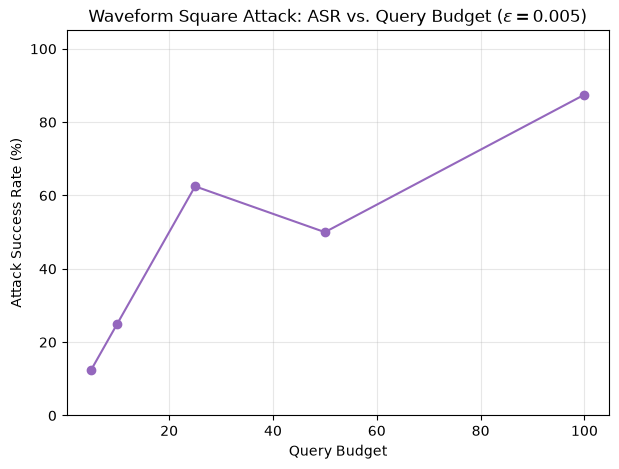

In [5]:
summary = results_df.groupby('QueryBudget')['Success'].mean() * 100

plt.figure(figsize=(7, 5))
plt.plot(summary.index, summary.values, 'o-', color='tab:purple')
plt.xlabel('Query Budget')
plt.ylabel('Attack Success Rate (%)')
plt.title(f'Waveform Square Attack: ASR vs. Query Budget ($\\varepsilon={EPSILON}$)')
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.show()